# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u

In [2]:
!pip install astroquery
from astroquery.sdss import SDSS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.8 MB/s eta 0:00:00


# Loading in Galaxy Sample

In [4]:
url = "https://raw.githubusercontent.com/cthitch137/Galaxy-Population-Study/refs/heads/main/data/galaxy_sample.csv"
df = pd.read_csv(url)

In [5]:
df

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,modelMagErr_u,modelMagErr_g,modelMagErr_r,modelMagErr_i,modelMagErr_z,snMedian,low_z
0,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,0.076137,0.010410,0.007362,0.007730,0.020277,10.20291,True
1,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,0.156786,0.014480,0.006870,0.006445,0.015181,11.13883,False
2,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,0.099035,0.011311,0.006693,0.006630,0.015336,13.57714,False
3,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,16.11972,0.096985,0.009497,0.005328,0.005129,0.011014,16.28147,False
4,1237648720142270656,146.432797,-0.987378,3.590598,0.140472,GALAXY,20.43741,18.42003,17.31446,16.85592,16.49146,0.081921,0.009217,0.005610,0.005561,0.011894,15.94299,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1812,1237657630064574618,179.185816,52.784357,4.921969,0.068700,GALAXY,18.95556,17.50044,16.79793,16.44113,16.17238,0.033074,0.005400,0.004432,0.004702,0.010381,17.45897,True
1813,1237651800162304205,154.437788,-0.732376,4.367133,0.085777,GALAXY,19.10930,17.93893,17.39034,17.01727,16.83489,0.040881,0.008041,0.008367,0.007289,0.021053,12.43208,True
1814,1237651800162238663,154.266041,-0.631991,4.272007,0.050029,GALAXY,19.45912,17.73841,16.95952,16.55442,16.25257,0.046473,0.006473,0.005202,0.004929,0.011036,18.32790,True
1815,1237657630064705676,179.785663,52.973089,4.662381,0.066440,GALAXY,18.47779,17.03031,16.41874,15.98532,15.78269,0.023839,0.004537,0.003878,0.003971,0.007895,20.19475,True


---
## Pulling emission line data from SDSS for BPT classification

We're looking to pull four emission lines from SDSS: **[OIII], Hβ, [NII], Hα**.

By taking the ratio of the lines (OIII/Hβ and NII/Hα), we can tell what is ionizing the gas in a galaxy. When looking for AGNs, their high energy ionization produces different ratios than those from young hot stars in star forming regions.



In [18]:
query = f"""
SELECT TOP 10000
  s.bestObjID as objid,
  g.oiii_5007_flux, g.oiii_5007_flux_err,
  g.h_beta_flux, g.h_beta_flux_err,
  g.nii_6584_flux, g.nii_6584_flux_err,
  g.h_alpha_flux, g.h_alpha_flux_err
FROM galSpecLine g
JOIN SpecObj s ON g.specobjid = s.specobjid
WHERE s.z BETWEEN 0.02 AND 0.25
AND s.class = 'GALAXY'
AND s.sciencePrimary = 1
"""

result = SDSS.query_sql(query)
df_lines = result.to_pandas()

df_bpt = df.merge(df_lines, on='objid', how='inner')
df_bpt = df_bpt.drop_duplicates(subset='objid', keep='first')
df_bpt = df_bpt.reset_index(drop=True)
print(f"Galaxies with emission line data: {len(df_bpt)}")


Galaxies with emission line data: 572


In [7]:
df_bpt

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,...,snMedian,low_z,oiii_5007_flux,oiii_5007_flux_err,h_beta_flux,h_beta_flux_err,nii_6584_flux,nii_6584_flux_err,h_alpha_flux,h_alpha_flux_err
0,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,...,10.20291,True,0.486909,1.677912,4.143331,2.936817,3.431805,2.359388,5.432809,4.066201
1,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,...,11.13883,False,0.486909,1.677912,4.143331,2.936817,3.431805,2.359388,5.432809,4.066201
2,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,...,13.57714,False,24.884370,4.390250,11.455300,3.146167,59.580810,6.234332,33.510510,3.762324
3,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,...,16.28147,False,24.884370,4.390250,11.455300,3.146167,59.580810,6.234332,33.510510,3.762324
4,1237648720142270656,146.432797,-0.987378,3.590598,0.140472,GALAXY,20.43741,18.42003,17.31446,16.85592,...,15.94299,False,0.247369,2.104005,0.197604,2.447149,3.657269,1.796134,0.944583,2.082906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,1237651800699109510,154.279707,-0.213573,4.188159,0.096856,GALAXY,20.47799,18.35708,17.39792,16.97565,...,13.69140,True,3.814561,4.112516,3.209878,2.067275,1.198949,3.357665,3.194017,1.831740
568,1237651800699109417,154.242701,-0.248031,9.314919,0.062911,GALAXY,18.47404,16.97748,16.31883,15.96845,...,10.09348,True,5.988339,1.956440,18.577980,1.993633,22.194840,1.910221,69.174720,2.584629
569,1237651800699043977,154.120599,-0.269819,3.230929,0.070977,GALAXY,19.50115,17.67237,16.72367,16.30329,...,21.84649,True,4.541171,2.126682,6.109835,5.616798,1.569630,1.995873,26.792480,5.782663
570,1237651800162304205,154.437788,-0.732376,4.367133,0.085777,GALAXY,19.10930,17.93893,17.39034,17.01727,...,12.43208,True,21.070950,2.345554,99.569630,2.847001,152.364600,2.715852,445.798100,4.639384


In [8]:
print(f"Full sample: {len(df)}")
print(f"Galaxies with emission line data: {len(df_bpt)}")
print(f"Fraction of full sample with emission lines: {len(df_bpt)/len(df):.2f}")

Full sample: 1817
Galaxies with emission line data: 572
Fraction of full sample with emission lines: 0.31


In [19]:
sn_cut = (
    (df_bpt['oiii_5007_flux'] / df_bpt['oiii_5007_flux_err'] > 3) &
    (df_bpt['h_beta_flux'] / df_bpt['h_beta_flux_err'] > 3) &
    (df_bpt['nii_6584_flux'] / df_bpt['nii_6584_flux_err'] > 3) &
    (df_bpt['h_alpha_flux'] / df_bpt['h_alpha_flux_err'] > 3)
)

df_bpt = df_bpt[sn_cut]

In [20]:
df_bpt['log_nii_ha'] = np.log10(df_bpt['nii_6584_flux'] / df_bpt['h_alpha_flux'])
df_bpt['log_oiii_hb'] = np.log10(df_bpt['oiii_5007_flux'] / df_bpt['h_beta_flux'])

In [38]:
bpt_range = (
    (df_bpt['log_nii_ha'].between(-2, 1)) &
    (df_bpt['log_oiii_hb'].between(-1.5, 1.5))
)

print(f"After range cuts: {len(df_bpt[bpt_range])}")

df_bpt = df_bpt[bpt_range]

After range cuts: 242


In [45]:
x = np.linspace(-1.5, 0, 100)

kauf = 0.61 / (x - 0.05) + 1.3  # Kauffmann et al. 2003 - empirical SF/composite boundary
kewl = 0.61 / (x - 0.47) + 1.19 # Kewley et al. 2001 - theoretical maximum starburst line

sf = (df_bpt['log_nii_ha'] < 0.05) & (df_bpt['log_oiii_hb'] < (0.61 / (df_bpt['log_nii_ha'] - 0.05) + 1.3))   # Star forming
agn = (df_bpt['log_nii_ha'] >= 0.47) | (df_bpt['log_oiii_hb'] > (0.61 / (df_bpt['log_nii_ha'] - 0.47) + 1.19)) # AGNs
comp = ~sf & ~agn

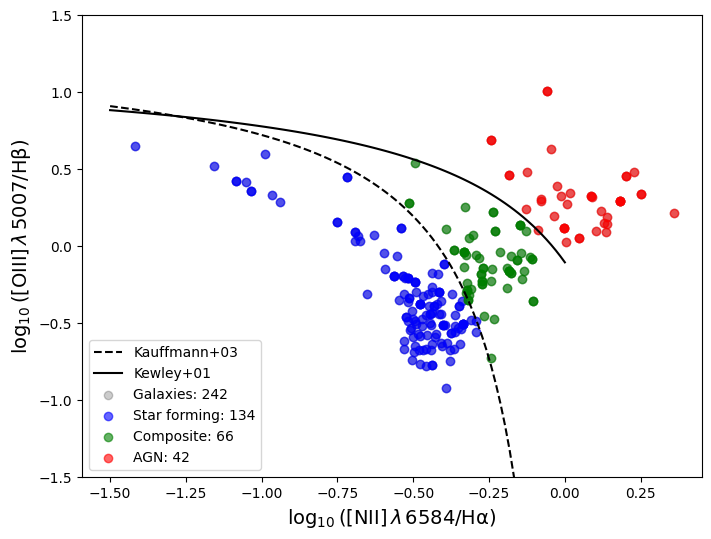

In [47]:
plt.figure(figsize=(8,6))
plt.plot(x, kauf, 'k--', label="Kauffmann+03")
plt.plot(x, kewl, 'k-', label="Kewley+01")

plt.scatter(df_bpt['log_nii_ha'], df_bpt['log_oiii_hb'], c='k', alpha=0.2, label=f"Galaxies: {len(df_bpt)}")
plt.scatter(df_bpt[sf]['log_nii_ha'], df_bpt[sf]['log_oiii_hb'], c='blue', alpha=0.6, label=f"Star forming: {sf.sum()}")
plt.scatter(df_bpt[comp]['log_nii_ha'], df_bpt[comp]['log_oiii_hb'], c='green', alpha=0.6, label=f"Composite: {comp.sum()}")
plt.scatter(df_bpt[agn]['log_nii_ha'], df_bpt[agn]['log_oiii_hb'], c='red', alpha=0.6, label=f"AGN: {agn.sum()}")


#plt.xlim(-2, 1)
plt.ylim(-1.5, 1.5)
plt.xlabel(r'$\log_{10}(\text{[NII]} \, \lambda \, 6584 \text{/Hα})$', fontsize = 14)
plt.ylabel(r'$\log_{10}(\text{[OIII]} \, \lambda \, 5007 \text{/Hβ})$', fontsize = 14)

plt.legend()

In [49]:
df_bpt['bpt_class'] = 'composite'
df_bpt.loc[sf, 'bpt_class'] = 'star_forming'
df_bpt.loc[agn, 'bpt_class'] = 'agn'

In [51]:
df = df.merge(df_bpt[['objid', 'bpt_class']], on='objid', how='left')
df['bpt_class'] = df['bpt_class'].fillna('no_emission')

In [52]:
df

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,modelMagErr_u,modelMagErr_g,modelMagErr_r,modelMagErr_i,modelMagErr_z,snMedian,low_z,bpt_class
0,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,0.076137,0.010410,0.007362,0.007730,0.020277,10.20291,True,no_emission
1,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,0.156786,0.014480,0.006870,0.006445,0.015181,11.13883,False,no_emission
2,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,0.099035,0.011311,0.006693,0.006630,0.015336,13.57714,False,agn
3,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,16.11972,0.096985,0.009497,0.005328,0.005129,0.011014,16.28147,False,agn
4,1237648720142270656,146.432797,-0.987378,3.590598,0.140472,GALAXY,20.43741,18.42003,17.31446,16.85592,16.49146,0.081921,0.009217,0.005610,0.005561,0.011894,15.94299,False,no_emission
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1812,1237657630064574618,179.185816,52.784357,4.921969,0.068700,GALAXY,18.95556,17.50044,16.79793,16.44113,16.17238,0.033074,0.005400,0.004432,0.004702,0.010381,17.45897,True,no_emission
1813,1237651800162304205,154.437788,-0.732376,4.367133,0.085777,GALAXY,19.10930,17.93893,17.39034,17.01727,16.83489,0.040881,0.008041,0.008367,0.007289,0.021053,12.43208,True,star_forming
1814,1237651800162238663,154.266041,-0.631991,4.272007,0.050029,GALAXY,19.45912,17.73841,16.95952,16.55442,16.25257,0.046473,0.006473,0.005202,0.004929,0.011036,18.32790,True,star_forming
1815,1237657630064705676,179.785663,52.973089,4.662381,0.066440,GALAXY,18.47779,17.03031,16.41874,15.98532,15.78269,0.023839,0.004537,0.003878,0.003971,0.007895,20.19475,True,no_emission


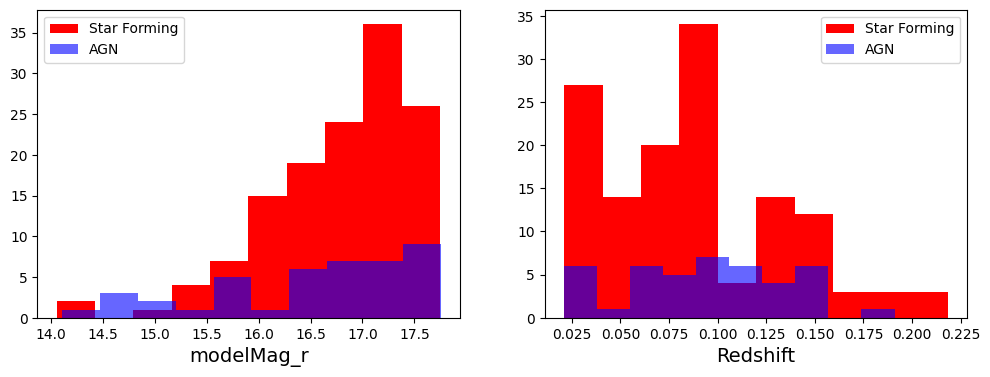

In [65]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(df[df['bpt_class']=='star_forming']['modelMag_r'], color='red', label='Star Forming')
axes[0].hist(df[df['bpt_class']=='agn']['modelMag_r'], color='blue', alpha=0.6, label='AGN')
axes[0].set_xlabel('modelMag_r', fontsize=14)
axes[0].legend()

axes[1].hist(df[df['bpt_class']=='star_forming']['z'], color='red', label='Star Forming')
axes[1].hist(df[df['bpt_class']=='agn']['z'], color='blue', alpha=0.6, label='AGN')
axes[1].set_xlabel('Redshift', fontsize=14)
axes[1].legend()